# Employee Salary Prediction Using Machine Learning

### Developed by: Vishu

---

## Project Overview

This project aims to predict employee salaries based on factors such as age, education, job title, years of experience, and gender using Multiple Linear Regression.

The project follows a complete Machine Learning workflow including:
- Data Collection
- Data Cleaning
- Exploratory Data Analysis (EDA)
- Feature Engineering
- Model Building
- Model Evaluation
- Business Insights

---

# 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings("ignore")

# 2. Load the Dataset

In [2]:
df = pd.read_csv("../data/salary_data.csv")

# 3. Understanding the Dataset

In [3]:
# Display the number of rows and columns
print("Dataset Shape:", df.shape)

Dataset Shape: (250000, 10)


In [4]:
# Display first 10 rows
df.head(10)

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069
5,AI Engineer,0,High School,4,Education,Enterprise,USA,No,2,180351
6,Backend Developer,6,High School,16,Manufacturing,Enterprise,Canada,No,3,165375
7,Machine Learning Engineer,4,Bachelor,18,Healthcare,Enterprise,Canada,Hybrid,5,202463
8,AI Engineer,5,Diploma,14,Telecom,Enterprise,Singapore,Yes,0,171834
9,Frontend Developer,18,PhD,2,Retail,Enterprise,India,Hybrid,5,128377


In [5]:
# Display all column names
print(df.columns.tolist())

['job_title', 'experience_years', 'education_level', 'skills_count', 'industry', 'company_size', 'location', 'remote_work', 'certifications', 'salary']


In [6]:
# Display information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   job_title         250000 non-null  object
 1   experience_years  250000 non-null  int64 
 2   education_level   250000 non-null  object
 3   skills_count      250000 non-null  int64 
 4   industry          250000 non-null  object
 5   company_size      250000 non-null  object
 6   location          250000 non-null  object
 7   remote_work       250000 non-null  object
 8   certifications    250000 non-null  int64 
 9   salary            250000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 19.1+ MB


In [7]:
# Summary of numerical columns
df.describe()

,experience_years,skills_count,certifications,salary
count,250000.000000,250000.000000,250000.000000,250000.000000
mean,10.005408,9.997812,2.491928,145718.080524
std,6.060602,5.479288,1.706475,37407.952729
min,0.000000,1.000000,0.000000,31867.000000
25%,5.000000,5.000000,1.000000,119358.000000
50%,10.000000,10.000000,2.000000,143453.000000
75%,15.000000,15.000000,4.000000,169492.000000
max,20.000000,19.000000,5.000000,333046.000000


In [8]:
# Summary of categorical columns
df.describe(include='object')

,job_title,education_level,industry,company_size,location,remote_work
count,250000,250000,250000,250000,250000,250000
unique,12,5,10,5,10,3
top,Backend Developer,Master,Finance,Large,Australia,No
freq,21125,50352,25393,50254,25258,83621


In [9]:
# Check for missing values
df.isnull().sum()

job_title           0
experience_years    0
education_level     0
skills_count        0
industry            0
company_size        0
location            0
remote_work         0
certifications      0
salary              0
dtype: int64

In [10]:
# Check duplicate rows
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [11]:
# Display unique values in each column
for column in df.columns:
    print(f"\n{column}")
    print(df[column].nunique())


job_title
12

experience_years
21

education_level
5

skills_count
19

industry
10

company_size
5

location
10

remote_work
3

certifications
6

salary
118956


# 4. Data Cleaning

In [12]:
df_clean = df.copy()

In [13]:
print("Missing Values:\n")
print(df_clean.isnull().sum())

Missing Values:

job_title           0
experience_years    0
education_level     0
skills_count        0
industry            0
company_size        0
location            0
remote_work         0
certifications      0
salary              0
dtype: int64


In [14]:
df_clean.drop_duplicates(inplace=True)

In [15]:
df_clean.columns = df_clean.columns.str.strip()

In [16]:
for col in df_clean.select_dtypes(include='object').columns:
    df_clean[col] = df_clean[col].str.strip()

In [17]:
print("\nDuplicate Rows:", df_clean.duplicated().sum())


Duplicate Rows: 0


In [18]:
print("\nDataset Shape:", df_clean.shape)


Dataset Shape: (250000, 10)


In [19]:
# Fill missing values
for col in df_clean.columns:
    if df_clean[col].dtype == 'object':
        df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)
    else:
        df_clean[col].fillna(df_clean[col].median(), inplace=True)

In [20]:
# Verify missing values
print(df_clean.isnull().sum())

job_title           0
experience_years    0
education_level     0
skills_count        0
industry            0
company_size        0
location            0
remote_work         0
certifications      0
salary              0
dtype: int64


In [21]:
# Numerical columns
numerical_columns = df_clean.select_dtypes(include=['int64', 'float64']).columns

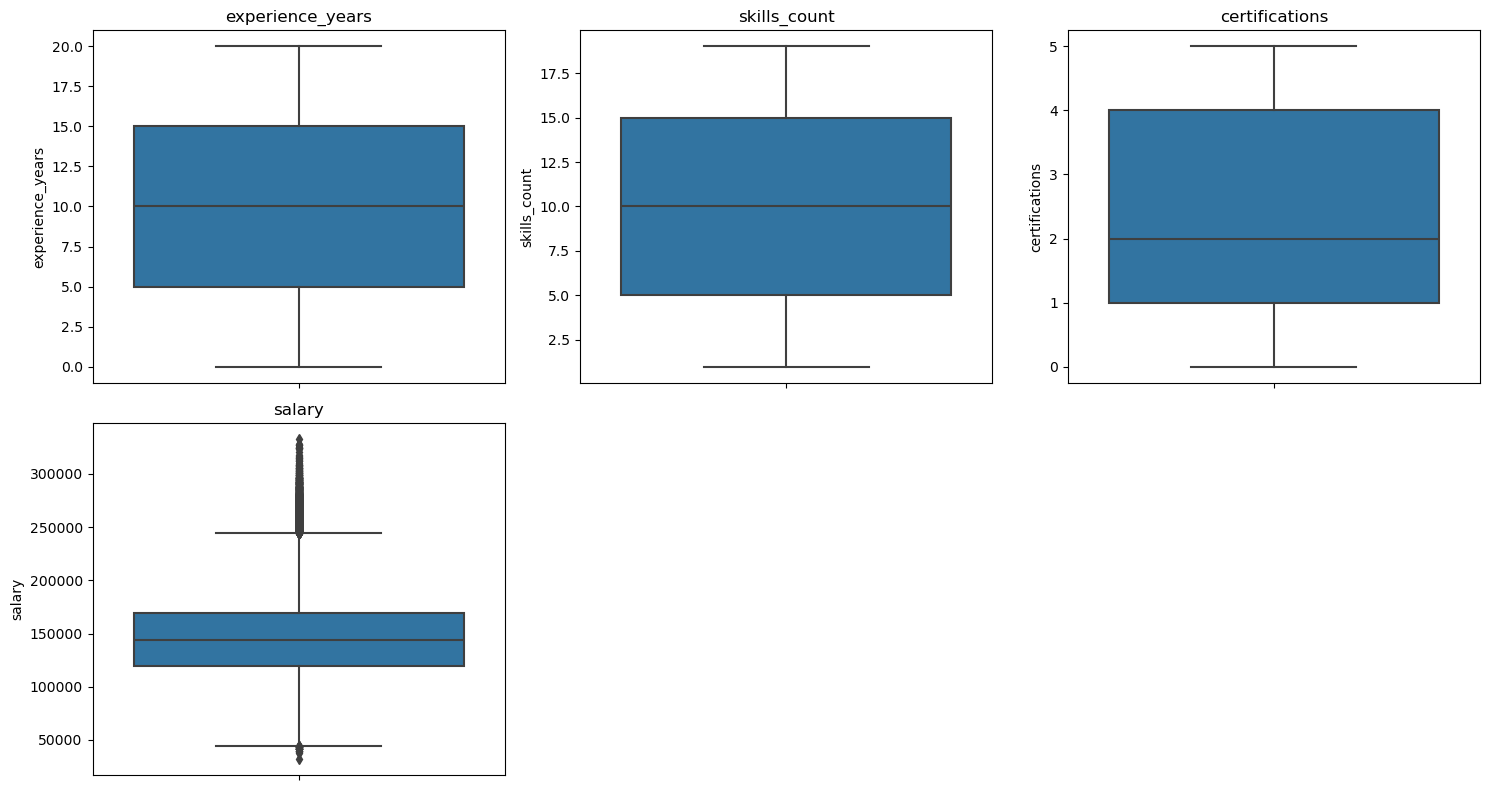

In [22]:
# Boxplots
plt.figure(figsize=(15,8))

for i, col in enumerate(numerical_columns, 1):
    plt.subplot((len(numerical_columns)+2)//3, 3, i)
    sns.boxplot(y=df_clean[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [23]:
df_clean.head()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


# 5. Exploratory Data Analysis (EDA)

## 5.1 Salary Distribution

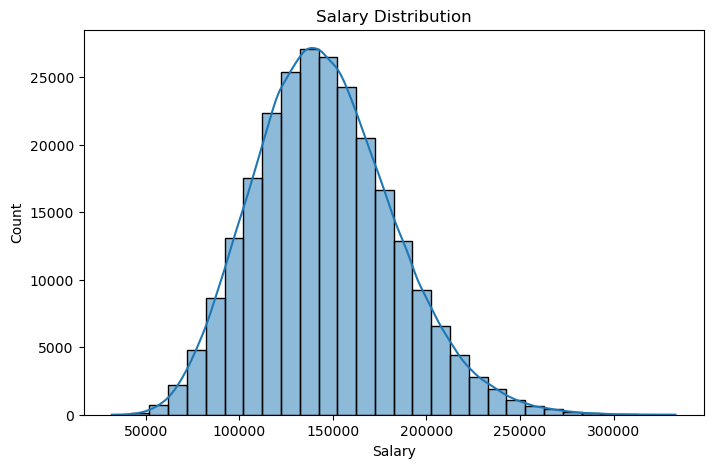

In [24]:
plt.figure(figsize=(8,5))
sns.histplot(df_clean['salary'], bins=30, kde=True)
plt.title('Salary Distribution')
plt.xlabel('Salary')
plt.ylabel('Count')
plt.show()

## 5.2 Experience vs Salary

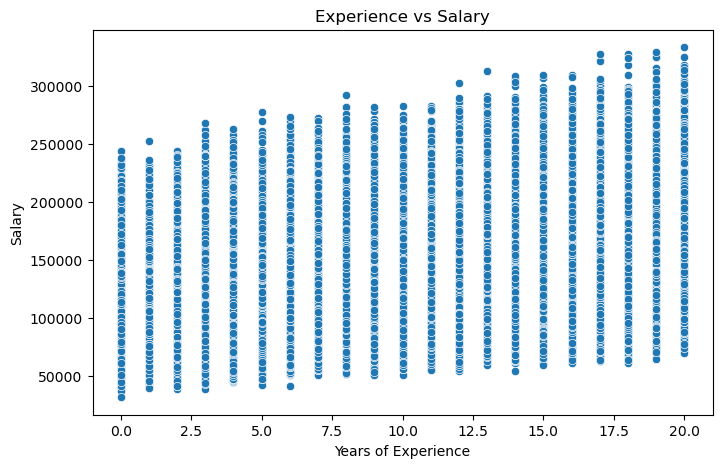

In [25]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df_clean, x='experience_years', y='salary')
plt.title('Experience vs Salary')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.show()

## 5.3 Education Level vs Salary

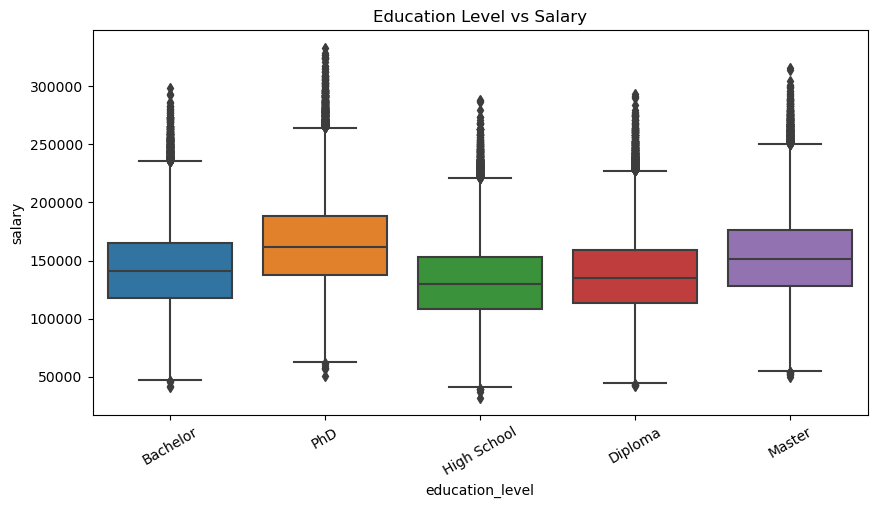

In [26]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df_clean, x='education_level', y='salary')
plt.title('Education Level vs Salary')
plt.xticks(rotation=30)
plt.show()

## 5.4 Company Size vs Salary

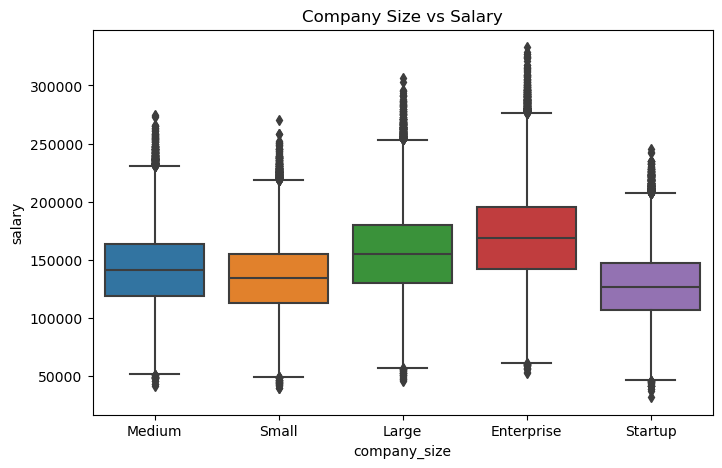

In [27]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df_clean, x='company_size', y='salary')
plt.title('Company Size vs Salary')
plt.show()

## 5.5 Remote Work Distribution

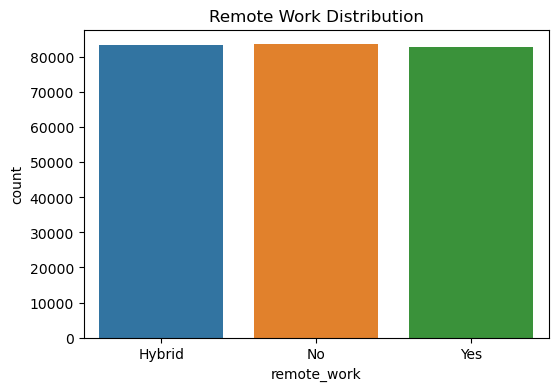

In [28]:
plt.figure(figsize=(6,4))
sns.countplot(data=df_clean, x='remote_work')
plt.title('Remote Work Distribution')
plt.show()

## 5.6 Top 10 Job Titles

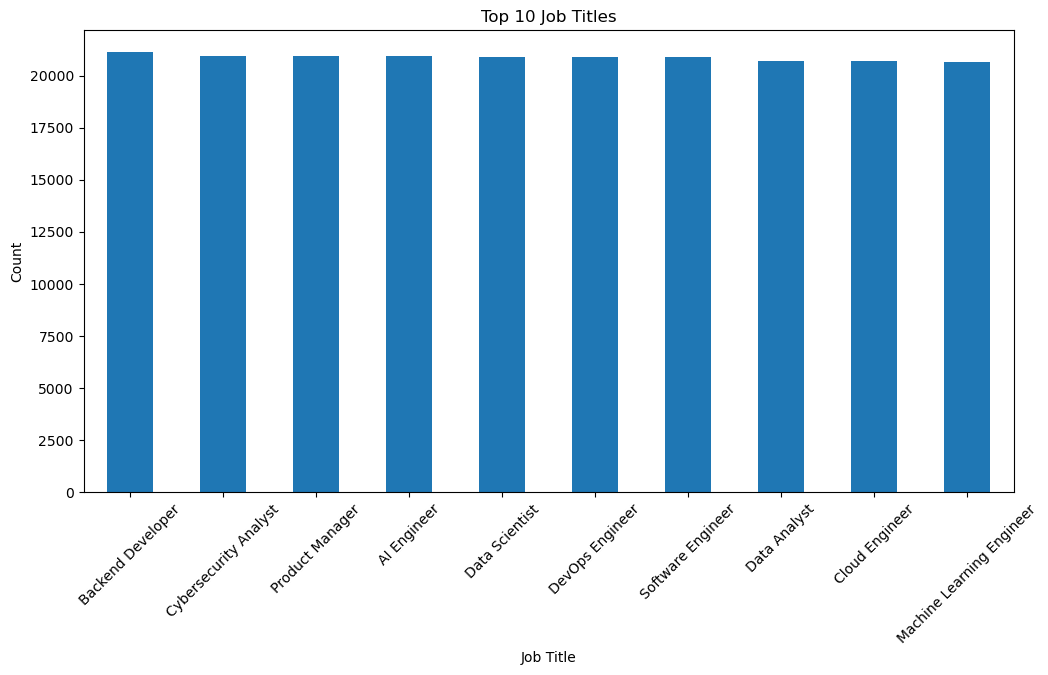

In [29]:
plt.figure(figsize=(12,6))
df_clean['job_title'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Job Titles')
plt.xlabel('Job Title')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

## 5.7 Correlation Heatmap

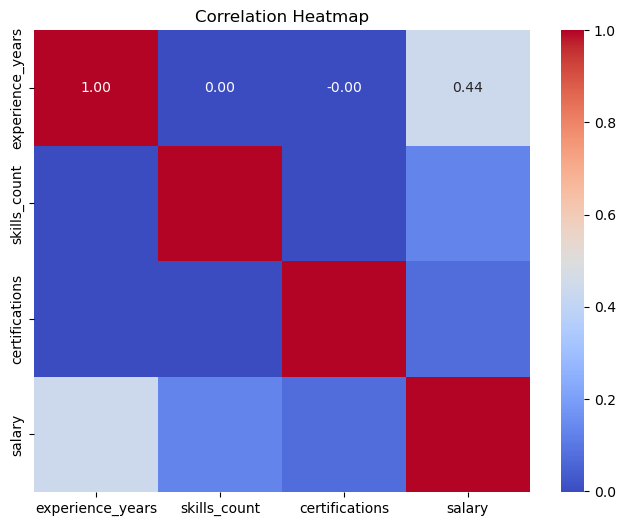

In [30]:
plt.figure(figsize=(8,6))

numeric_df = df_clean.select_dtypes(include=['int64','float64'])

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Correlation Heatmap')
plt.show()

## 5.8 Skills Count vs Salary

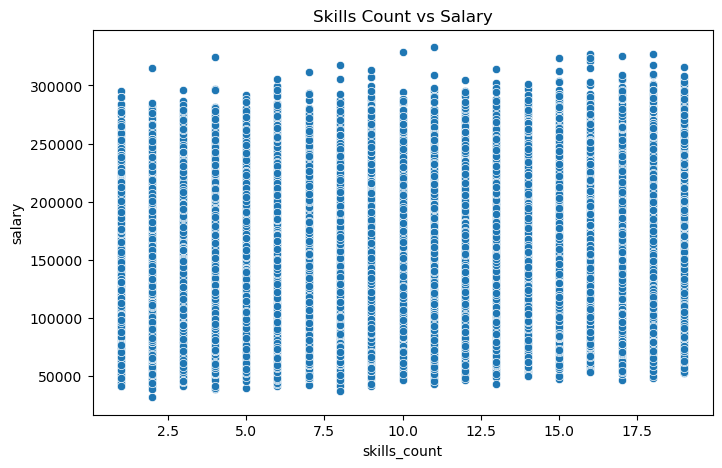

In [31]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df_clean, x='skills_count', y='salary')
plt.title('Skills Count vs Salary')
plt.show()

## 5.9 Certifications vs Salary

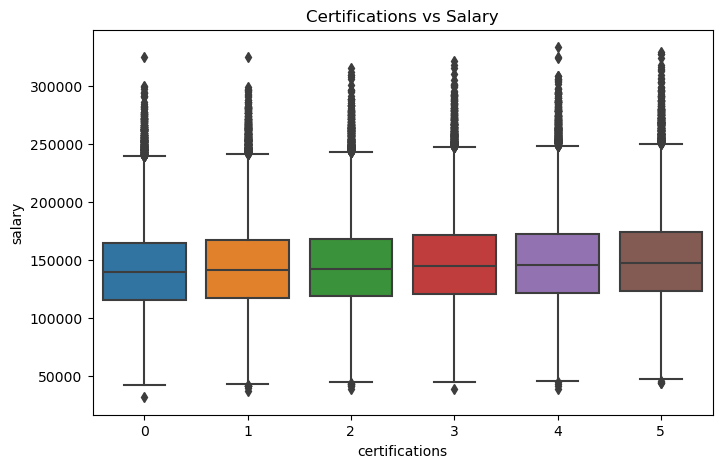

In [32]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df_clean, x='certifications', y='salary')
plt.title('Certifications vs Salary')
plt.show()

## 5.10 Industry-wise Average Salary

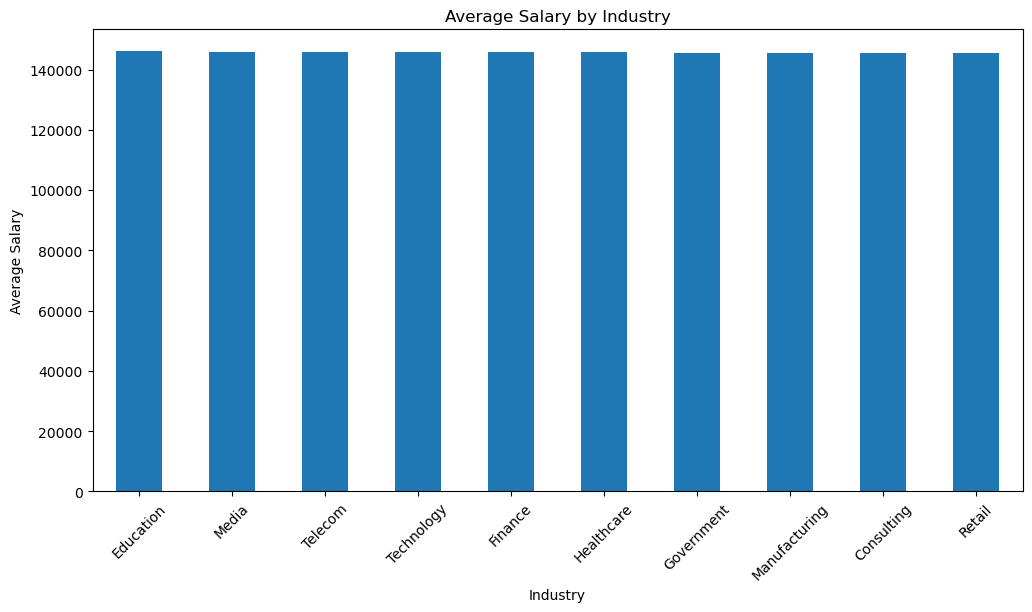

In [33]:
plt.figure(figsize=(12,6))

industry_salary = df_clean.groupby('industry')['salary'].mean().sort_values(ascending=False)

industry_salary.plot(kind='bar')

plt.title('Average Salary by Industry')
plt.xlabel('Industry')
plt.ylabel('Average Salary')

plt.xticks(rotation=45)

plt.show()

# 6. Feature Engineering

In [34]:
X = df_clean.drop('salary', axis=1)
y = df_clean['salary']

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (250000, 9)
Target Shape: (250000,)


## 6.1 Separate Features and Target Variable

## 6.2 Encode Categorical Features

In [35]:
X = pd.get_dummies(X, drop_first=True)

print(X.head())

   experience_years  skills_count  certifications  \
0                10             2               2   
1                 5            17               0   
2                18             4               1   
3                19            13               0   
4                15             7               0   

   job_title_Backend Developer  job_title_Business Analyst  \
0                        False                       False   
1                        False                       False   
2                        False                       False   
3                        False                        True   
4                        False                       False   

   job_title_Cloud Engineer  job_title_Cybersecurity Analyst  \
0                     False                            False   
1                     False                            False   
2                     False                            False   
3                     False                         

## 6.3 Verify Encoded Dataset

In [36]:
print("Encoded Dataset Shape:", X.shape)

X.head()

Encoded Dataset Shape: (250000, 42)


,experience_years,skills_count,certifications,job_title_Backend Developer,job_title_Business Analyst,job_title_Cloud Engineer,job_title_Cybersecurity Analyst,job_title_Data Analyst,job_title_Data Scientist,job_title_DevOps Engineer,...,location_Germany,location_India,location_Netherlands,location_Remote,location_Singapore,location_Sweden,location_UK,location_USA,remote_work_No,remote_work_Yes
0,10,2,2,False,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
1,5,17,0,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,True,False
2,18,4,1,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,True,False
3,19,13,0,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4,15,7,0,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,True


# 7. Train-Test Split

## 7.1 Split the Dataset

In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (200000, 42)
Testing Data Shape: (50000, 42)


# 8. Model Building

## 8.1 Train Multiple Linear Regression Model

In [38]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

print("Model Training Completed Successfully!")

Model Training Completed Successfully!


## 8.2 Make Predictions

In [39]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[172850.85075644  89234.51820968  63791.55580144 168311.83087157
 117222.93245304 171755.3465471  110424.89372537  60449.43324415
  93094.30545676 192448.9614344 ]


# 9. Model Evaluation

## 9.1 Evaluate Model Performance

In [40]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error : {mae:.2f}")
print(f"Mean Squared Error  : {mse:.2f}")
print(f"Root Mean Squared Error : {rmse:.2f}")
print(f"R2 Score : {r2:.4f}")

Mean Absolute Error : 5436.10
Mean Squared Error  : 50773076.66
Root Mean Squared Error : 7125.52
R2 Score : 0.9635


## 9.2 Actual vs Predicted Salary

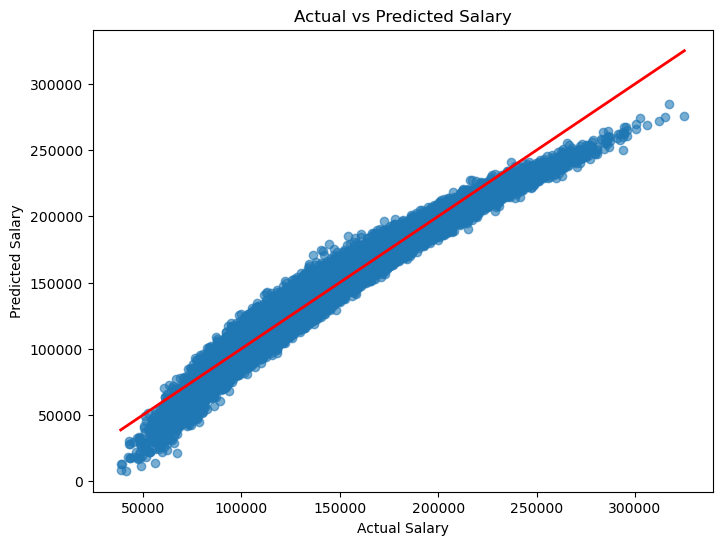

In [41]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linewidth=2
)

plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted Salary")

plt.show()

## 9.3 Residual Analysis

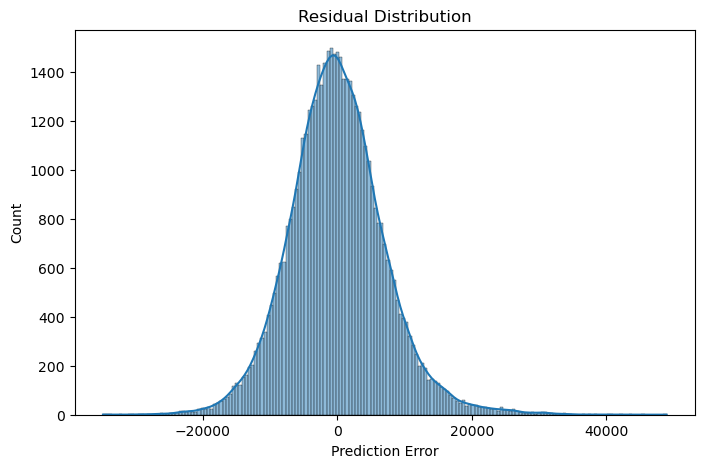

In [42]:
residuals = y_test - y_pred

plt.figure(figsize=(8,5))

sns.histplot(residuals, kde=True)

plt.title("Residual Distribution")
plt.xlabel("Prediction Error")

plt.show()

# 10. Business Insights

## 10.1 Key Insights

In [43]:
print("Key Business Insights")
print("-" * 50)

print("1. Employees with more years of experience generally receive higher salaries.")
print("2. Higher education levels are associated with better salary packages.")
print("3. Employees with more skills tend to earn higher salaries.")
print("4. Certain industries offer significantly higher average salaries than others.")
print("5. Company size also has an impact on employee compensation.")
print("6. The trained model can help organizations estimate salaries for new candidates.")

Key Business Insights
--------------------------------------------------
1. Employees with more years of experience generally receive higher salaries.
2. Higher education levels are associated with better salary packages.
3. Employees with more skills tend to earn higher salaries.
4. Certain industries offer significantly higher average salaries than others.
5. Company size also has an impact on employee compensation.
6. The trained model can help organizations estimate salaries for new candidates.


# 11. Conclusion

This project demonstrates how Machine Learning can be used to predict employee salaries based on various employee attributes. The model was evaluated using multiple regression metrics, and exploratory data analysis helped identify key factors influencing salary.

Future improvements may include:
- Testing advanced regression algorithms.
- Hyperparameter tuning.
- Deploying the model as a web application using Streamlit.

In [44]:
print("Project Conclusion")
print("-" * 50)

print("The Multiple Linear Regression model successfully predicts employee salaries using multiple employee-related features.")
print("The project demonstrates the complete machine learning workflow, including data cleaning, exploratory data analysis, feature engineering, model training, and evaluation.")
print(f"\nModel R² Score: {r2:.4f}")
print(f"Model RMSE: {rmse:.2f}")

Project Conclusion
--------------------------------------------------
The Multiple Linear Regression model successfully predicts employee salaries using multiple employee-related features.
The project demonstrates the complete machine learning workflow, including data cleaning, exploratory data analysis, feature engineering, model training, and evaluation.

Model R² Score: 0.9635
Model RMSE: 7125.52


# 12. Future Scope

In [45]:
print("Future Scope")
print("-" * 50)

print("• Compare Multiple Linear Regression with Random Forest and XGBoost.")
print("• Perform hyperparameter tuning to improve prediction accuracy.")
print("• Build an interactive salary prediction web application using Streamlit.")
print("• Deploy the project on Streamlit Cloud or Render.")
print("• Integrate the model with a real-world HR recruitment system.")

Future Scope
--------------------------------------------------
• Compare Multiple Linear Regression with Random Forest and XGBoost.
• Perform hyperparameter tuning to improve prediction accuracy.
• Build an interactive salary prediction web application using Streamlit.
• Deploy the project on Streamlit Cloud or Render.
• Integrate the model with a real-world HR recruitment system.


# 13. Save the Trained Model

In [46]:
import joblib

joblib.dump(model, "salary_prediction_model.pkl")

print("Model saved successfully as salary_prediction_model.pkl")

Model saved successfully as salary_prediction_model.pkl


# 14. Build Deployment Model

In [47]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
import joblib

# Features and target
X = df_clean.drop("salary", axis=1)
y = df_clean["salary"]

# Categorical and numerical columns
categorical_cols = X.select_dtypes(include="object").columns
numerical_cols = X.select_dtypes(exclude="object").columns

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numerical_cols)
    ]
)

# Pipeline
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

# Train
pipeline.fit(X, y)

# Save
joblib.dump(pipeline, "salary_prediction_pipeline.pkl")

print("Pipeline model saved successfully!")

Pipeline model saved successfully!
